In [3]:
import pandas as pd
from pathlib import Path

BASE = Path(r'B:\Semester 4 UU\thesis-best-paper-trajectories')
DATA_MATCHED = BASE / 'data' / 'matched'

# Authors on award papers (internal award_id etc.)
award_authors = pd.read_csv(DATA_MATCHED / 'all_authors_within_paper.csv')

# Edges: which papers cite which award papers (OpenAlex award_paper_id)
award_to_citing = pd.read_csv(DATA_MATCHED / 'award_to_citing_edges.csv')

# Metadata for papers in the citation graph
cited_papers = pd.read_csv(DATA_MATCHED / 'cited_papers.csv')

# Huang file: gives OpenAlex id + award year / conference
huang = pd.read_csv(DATA_MATCHED / 'huang_matched_openalex.csv')

# Build mapping from OpenAlex award paper id -> award year, conference
award_map = huang[['openalex_id', 'year', 'conference']].drop_duplicates()
award_map = award_map.rename(columns={
    'openalex_id': 'award_paper_id',
    'year': 'award_year',
    'conference': 'award_conference'
})

award_authors.head(), award_to_citing.head(), award_map.head()

(   award_id conference  award_year    author_id     author_name  position  \
 0         1       AAAI        2018  A5026521600    Chenjun Xiao         1   
 1         1       AAAI        2018  A5014823249    Jincheng Mei         2   
 2         1       AAAI        2018  A5010677076  Martin Müller         3   
 3         2        ACL        2018  A5054978902       John Hale         1   
 4         2        ACL        2018  A5111222692      Chris Dyer         2   
 
    career_age  total_pubs seniority  \
 0           6          43    senior   
 1           4          29    junior   
 2          52         170    senior   
 3          88          84    senior   
 4          48         377    senior   
 
                                       counts_by_year  
 0  [{"year": 2012, "works_count": 2, "cited_by_co...  
 1  [{"year": 2014, "works_count": 3, "cited_by_co...  
 2  [{"year": 1966, "works_count": 1, "cited_by_co...  
 3  [{"year": 1930, "works_count": 1, "cited_by_co...  
 4  [{"y

In [16]:
# Build citing-paper authors from cited_papers.csv
citing_meta = cited_papers[['openalex_id', 'publication_year', 'author_ids']].copy()
citing_meta = citing_meta.rename(columns={
    'openalex_id': 'citing_paper_id',
    'publication_year': 'citing_year'
})

citing_meta['author_ids'] = citing_meta['author_ids'].fillna('')
citing_meta_exploded = (
    citing_meta
    .assign(author_id_str=citing_meta['author_ids'].str.split('|'))
    .explode('author_id_str')
)
citing_meta_exploded['author_id'] = citing_meta_exploded['author_id_str'].str.strip()

citing_authors = citing_meta_exploded[
    citing_meta_exploded['author_id'] != ''
].drop(columns=['author_ids', 'author_id_str'])

citing_authors.head()

,citing_paper_id,citing_year,author_id
0,https://openalex.org/W103650626,2000.0,https://openalex.org/A5042523975
0,https://openalex.org/W103650626,2000.0,https://openalex.org/A5004464753
1,https://openalex.org/W102708294,2007.0,https://openalex.org/A5071765665
1,https://openalex.org/W102708294,2007.0,https://openalex.org/A5076876024
1,https://openalex.org/W102708294,2007.0,https://openalex.org/A5007353660


In [20]:
# Cell 3: assume award_to_citing already has award_year and award_conference

# 1) Ensure citing_year is present on edges
if 'citing_year' not in award_to_citing.columns:
    award_to_citing = award_to_citing.merge(
        citing_authors[['citing_paper_id', 'citing_year']].drop_duplicates(),
        on='citing_paper_id',
        how='left'
    )

# 2) Filter to post-award citing papers
citing_award = award_to_citing[
    award_to_citing['citing_year'] >= award_to_citing['award_year']
].copy()

print('Edges post-award:', citing_award.shape)
citing_award.head()

Edges post-award: (3836, 5)


,award_paper_id,award_year,award_conference,citing_paper_id,citing_year
197,https://openalex.org/W2899300759,2018,ACL,https://openalex.org/W3013227230,2020.0
2315,https://openalex.org/W2807472134,2018,CHI,https://openalex.org/W2807472134,2018.0
3463,https://openalex.org/W2963124215,2018,FOCS,https://openalex.org/W2963124215,2018.0
3628,https://openalex.org/W2787022562,2018,FOCS,https://openalex.org/W2787022562,2018.0
3629,https://openalex.org/W2787022562,2018,FOCS,https://openalex.org/W2798524658,2018.0


In [21]:
award_authors.columns, award_authors.head()

(Index(['award_id', 'conference', 'award_year', 'author_id', 'author_name',
        'position', 'career_age', 'total_pubs', 'seniority', 'counts_by_year'],
       dtype='object'),
    award_id conference  award_year    author_id     author_name  position  \
 0         1       AAAI        2018  A5026521600    Chenjun Xiao         1   
 1         1       AAAI        2018  A5014823249    Jincheng Mei         2   
 2         1       AAAI        2018  A5010677076  Martin Müller         3   
 3         2        ACL        2018  A5054978902       John Hale         1   
 4         2        ACL        2018  A5111222692      Chris Dyer         2   
 
    career_age  total_pubs seniority  \
 0           6          43    senior   
 1           4          29    junior   
 2          52         170    senior   
 3          88          84    senior   
 4          48         377    senior   
 
                                       counts_by_year  
 0  [{"year": 2012, "works_count": 2, "cited_by_co..

In [22]:
# From huang we only know openalex_id and award-year/conference
huang_map = huang[['openalex_id', 'year', 'conference']].drop_duplicates()

# We also know award_id, award_year, conference in award_authors
award_core = award_authors[['award_id', 'award_year', 'conference']].drop_duplicates()

# Merge on year+conference to link internal award_id to OpenAlex id
award_bridge = award_core.merge(
    huang_map,
    left_on=['award_year', 'conference'],
    right_on=['year', 'conference'],
    how='left'
)

# Rename for consistency
award_bridge = award_bridge.rename(columns={'openalex_id': 'award_paper_id'})
award_bridge = award_bridge[['award_id', 'award_paper_id', 'award_year', 'conference']].drop_duplicates()

award_bridge.head()

,award_id,award_paper_id,award_year,conference
0,1,https://openalex.org/W2788603415,2018,AAAI
1,2,https://openalex.org/W2798397965,2018,ACL
2,2,https://openalex.org/W2963033005,2018,ACL
3,2,https://openalex.org/W2899300759,2018,ACL
4,3,https://openalex.org/W2798397965,2018,ACL


In [23]:
# 6a) Add internal award_id to each edge using award_paper_id
citing_award_with_id = citing_award.merge(
    award_bridge[['award_id', 'award_paper_id']],
    on='award_paper_id',
    how='left'
)

# 6b) Prepare award-author table keyed by award_id
award_authors_small = award_authors[['award_id', 'author_id']].drop_duplicates()
award_authors_small = award_authors_small.rename(columns={'author_id': 'award_author_id'})

# 6c) Prepare citing-author table keyed by citing_paper_id
citing_authors_small = citing_authors[['citing_paper_id', 'author_id']].drop_duplicates()
citing_authors_small = citing_authors_small.rename(columns={'author_id': 'citing_author_id'})

# 6d) Attach citing authors to each award→citing edge
citing_award_authors = citing_award_with_id.merge(
    citing_authors_small,
    on='citing_paper_id',
    how='left'
)

citing_award_authors.head()

,award_paper_id,award_year,award_conference,citing_paper_id,citing_year,award_id,citing_author_id
0,https://openalex.org/W2899300759,2018,ACL,https://openalex.org/W3013227230,2020.0,2,https://openalex.org/A5089404860
1,https://openalex.org/W2899300759,2018,ACL,https://openalex.org/W3013227230,2020.0,3,https://openalex.org/A5089404860
2,https://openalex.org/W2899300759,2018,ACL,https://openalex.org/W3013227230,2020.0,4,https://openalex.org/A5089404860
3,https://openalex.org/W2807472134,2018,CHI,https://openalex.org/W2807472134,2018.0,5,https://openalex.org/A5028106242
4,https://openalex.org/W2807472134,2018,CHI,https://openalex.org/W2807472134,2018.0,5,https://openalex.org/A5090363920


In [24]:
# 7a) Attach award authors (one row per award author)
citing_award_full = citing_award_authors.merge(
    award_authors_small,
    on='award_id',
    how='left'
)

# 7b) Self-citation if citing author == one of that award's authors
citing_award_full['is_self_cite'] = (
    citing_award_full['citing_author_id'] == citing_award_full['award_author_id']
)

# Quick sanity check
print(citing_award_full['is_self_cite'].value_counts(dropna=False))
citing_award_full.head()

is_self_cite
False    145138
Name: count, dtype: int64


,award_paper_id,award_year,award_conference,citing_paper_id,citing_year,award_id,citing_author_id,award_author_id,is_self_cite
0,https://openalex.org/W2899300759,2018,ACL,https://openalex.org/W3013227230,2020.0,2,https://openalex.org/A5089404860,A5054978902,False
1,https://openalex.org/W2899300759,2018,ACL,https://openalex.org/W3013227230,2020.0,2,https://openalex.org/A5089404860,A5111222692,False
2,https://openalex.org/W2899300759,2018,ACL,https://openalex.org/W3013227230,2020.0,2,https://openalex.org/A5089404860,A5069646529,False
3,https://openalex.org/W2899300759,2018,ACL,https://openalex.org/W3013227230,2020.0,3,https://openalex.org/A5089404860,A5001484153,False
4,https://openalex.org/W2899300759,2018,ACL,https://openalex.org/W3013227230,2020.0,3,https://openalex.org/A5089404860,A5019928111,False


In [25]:
# Compute years since award for each citing event
citing_award_full['years_since_award'] = (
    citing_award_full['citing_year'] - citing_award_full['award_year']
)

# Keep only rows where we know if it's self-cite (True/False) and author ids are present
mask = citing_award_full['citing_author_id'].notna() & citing_award_full['award_author_id'].notna()
caf_clean = citing_award_full[mask].copy()

# Aggregate per award author and years since award
author_year_stats = (
    caf_clean
    .groupby(['award_id', 'award_author_id', 'years_since_award'], as_index=False)
    .agg(
        total_cites=('citing_paper_id', 'nunique'),
        self_cites=('is_self_cite', lambda x: x.sum()),
    )
)

author_year_stats['self_share'] = author_year_stats['self_cites'] / author_year_stats['total_cites']

author_year_stats.head()

,award_id,award_author_id,years_since_award,total_cites,self_cites,self_share
0,2,A5054978902,2.0,1,0,0.0
1,2,A5069646529,2.0,1,0,0.0
2,2,A5111222692,2.0,1,0,0.0
3,3,A5001484153,2.0,1,0,0.0
4,3,A5019928111,2.0,1,0,0.0


In [26]:
# Aggregate at award-paper level (overall, not per author)
paper_stats = (
    caf_clean
    .groupby(['award_id', 'award_paper_id'], as_index=False)
    .agg(
        total_cites=('citing_paper_id', 'nunique'),
        self_cites=('is_self_cite', lambda x: x.sum()),
    )
)

paper_stats['self_share'] = paper_stats['self_cites'] / paper_stats['total_cites']

paper_stats.head()

,award_id,award_paper_id,total_cites,self_cites,self_share
0,2,https://openalex.org/W2899300759,1,0,0.0
1,3,https://openalex.org/W2899300759,1,0,0.0
2,4,https://openalex.org/W2899300759,1,0,0.0
3,5,https://openalex.org/W2807472134,1,0,0.0
4,6,https://openalex.org/W2807472134,1,0,0.0


In [27]:
import matplotlib.pyplot as plt

# Bring seniority info onto the author-year stats
seniority_info = award_authors[['award_id', 'author_id', 'seniority']].drop_duplicates()
seniority_info = seniority_info.rename(columns={'author_id': 'award_author_id'})

author_year_stats_sen = author_year_stats.merge(
    seniority_info,
    on=['award_id', 'award_author_id'],
    how='left'
)

# Drop weird years (negative or NaN)
author_year_stats_sen = author_year_stats_sen[
    author_year_stats_sen['years_since_award'].notna()
    & (author_year_stats_sen['years_since_award'] >= 0)
]

# Average self-share by years_since_award and seniority
avg_self_share = (
    author_year_stats_sen
    .groupby(['years_since_award', 'seniority'], as_index=False)
    .agg(mean_self_share=('self_share', 'mean'),
         n_authors=('award_author_id', 'nunique'))
)

avg_self_share.head()

,years_since_award,seniority,mean_self_share,n_authors
0,0.0,junior,0.0,291
1,0.0,senior,0.0,723
2,1.0,junior,0.0,323
3,1.0,senior,0.0,742
4,2.0,junior,0.0,330


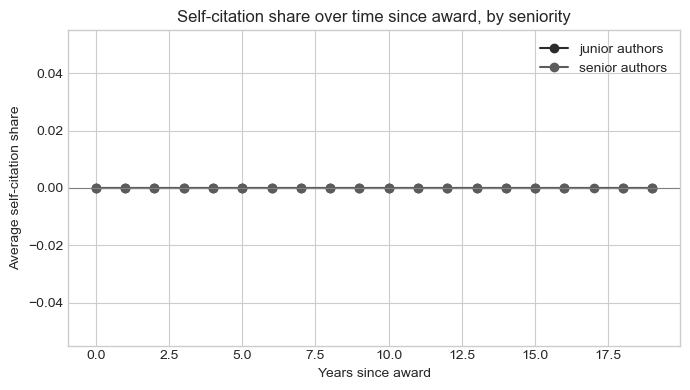

In [28]:
plt.figure(figsize=(7, 4))

for label, grp in avg_self_share.groupby('seniority'):
    plt.plot(
        grp['years_since_award'],
        grp['mean_self_share'],
        marker='o',
        label=f'{label} authors'
    )

plt.axhline(0, color='grey', linewidth=0.8)
plt.xlabel('Years since award')
plt.ylabel('Average self-citation share')
plt.title('Self-citation share over time since award, by seniority')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
print("Award author IDs sample:")
print(award_authors['author_id'].dropna().astype(str).head(10).tolist())

print("\nCiting author IDs sample:")
print(citing_authors['author_id'].dropna().astype(str).head(10).tolist())

Award author IDs sample:
['A5026521600', 'A5014823249', 'A5010677076', 'A5054978902', 'A5111222692', 'A5069646529', 'A5001484153', 'A5019928111', 'A5040699318', 'A5040685721']

Citing author IDs sample:
['https://openalex.org/A5042523975', 'https://openalex.org/A5004464753', 'https://openalex.org/A5071765665', 'https://openalex.org/A5076876024', 'https://openalex.org/A5007353660', 'https://openalex.org/A5067133778', 'https://openalex.org/A5110261572', 'https://openalex.org/A5063822723', 'https://openalex.org/A5006446297', 'https://openalex.org/A5100891241']


In [30]:
import re

def normalize_author_id(x):
    x = str(x)
    # remove markdown brackets if present
    x = re.sub(r'^\[|\]$', '', x)
    # if it's a markdown link like [url](url), take the part after the last slash
    if 'http' in x:
        # get inside the () first if markdown
        if '(' in x and ')' in x:
            x = x.split('(')[-1].split(')')[0]
        # then strip to last path component
        x = x.rstrip('/').split('/')[-1]
    return x

award_authors['author_id_norm'] = award_authors['author_id'].apply(normalize_author_id)
citing_authors['author_id_norm'] = citing_authors['author_id'].apply(normalize_author_id)

print("Award norm sample:", award_authors['author_id_norm'].head().tolist())
print("Citing norm sample:", citing_authors['author_id_norm'].head().tolist())

Award norm sample: ['A5026521600', 'A5014823249', 'A5010677076', 'A5054978902', 'A5111222692']
Citing norm sample: ['A5042523975', 'A5004464753', 'A5071765665', 'A5076876024', 'A5007353660']


In [31]:
# Rebuild small tables with normalized IDs
award_authors_small = award_authors[['award_id', 'author_id_norm']].drop_duplicates()
award_authors_small = award_authors_small.rename(columns={'author_id_norm': 'award_author_id'})

citing_authors_small = citing_authors[['citing_paper_id', 'author_id_norm']].drop_duplicates()
citing_authors_small = citing_authors_small.rename(columns={'author_id_norm': 'citing_author_id'})

# Re-attach citing authors to edges
citing_award_authors = citing_award_with_id.merge(
    citing_authors_small,
    on='citing_paper_id',
    how='left'
)

# Re-attach award authors
citing_award_full = citing_award_authors.merge(
    award_authors_small,
    on='award_id',
    how='left'
)

# New self-cite flag
citing_award_full['is_self_cite'] = (
    citing_award_full['citing_author_id'] == citing_award_full['award_author_id']
)

print(citing_award_full['is_self_cite'].value_counts(dropna=False))
citing_award_full.head()

is_self_cite
False    144083
True       1055
Name: count, dtype: int64


,award_paper_id,award_year,award_conference,citing_paper_id,citing_year,award_id,citing_author_id,award_author_id,is_self_cite
0,https://openalex.org/W2899300759,2018,ACL,https://openalex.org/W3013227230,2020.0,2,A5089404860,A5054978902,False
1,https://openalex.org/W2899300759,2018,ACL,https://openalex.org/W3013227230,2020.0,2,A5089404860,A5111222692,False
2,https://openalex.org/W2899300759,2018,ACL,https://openalex.org/W3013227230,2020.0,2,A5089404860,A5069646529,False
3,https://openalex.org/W2899300759,2018,ACL,https://openalex.org/W3013227230,2020.0,3,A5089404860,A5001484153,False
4,https://openalex.org/W2899300759,2018,ACL,https://openalex.org/W3013227230,2020.0,3,A5089404860,A5019928111,False


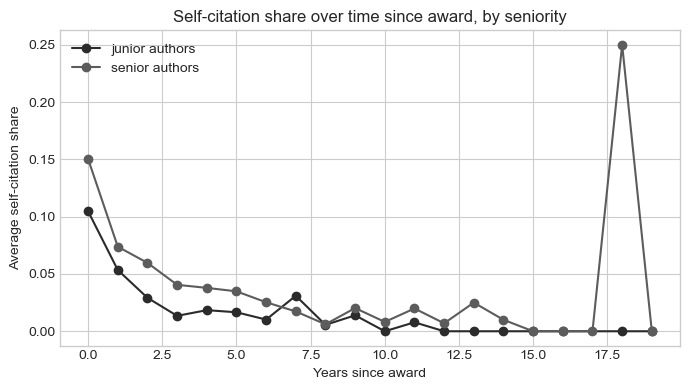

In [32]:
# years since award
citing_award_full['years_since_award'] = (
    citing_award_full['citing_year'] - citing_award_full['award_year']
)

mask = citing_award_full['citing_author_id'].notna() & citing_award_full['award_author_id'].notna()
caf_clean = citing_award_full[mask].copy()

author_year_stats = (
    caf_clean
    .groupby(['award_id', 'award_author_id', 'years_since_award'], as_index=False)
    .agg(
        total_cites=('citing_paper_id', 'nunique'),
        self_cites=('is_self_cite', lambda x: x.sum()),
    )
)
author_year_stats['self_share'] = author_year_stats['self_cites'] / author_year_stats['total_cites']

# add seniority and replot as before
seniority_info = award_authors[['award_id', 'author_id_norm', 'seniority']].drop_duplicates()
seniority_info = seniority_info.rename(columns={'author_id_norm': 'award_author_id'})

author_year_stats_sen = author_year_stats.merge(
    seniority_info,
    on=['award_id', 'award_author_id'],
    how='left'
)

author_year_stats_sen = author_year_stats_sen[
    author_year_stats_sen['years_since_award'].notna()
    & (author_year_stats_sen['years_since_award'] >= 0)
]

avg_self_share = (
    author_year_stats_sen
    .groupby(['years_since_award', 'seniority'], as_index=False)
    .agg(mean_self_share=('self_share', 'mean'))
)

plt.figure(figsize=(7, 4))
for label, grp in avg_self_share.groupby('seniority'):
    plt.plot(grp['years_since_award'], grp['mean_self_share'], marker='o', label=f'{label} authors')
plt.xlabel('Years since award')
plt.ylabel('Average self-citation share')
plt.title('Self-citation share over time since award, by seniority')
plt.legend()
plt.tight_layout()
plt.show()